# 1.6 Test evaluation

(1) Load raw test, (2) apply saved preprocessor, feature engineer and model (`transform` / `predict` only), (3) report test metrics.

| Artifact | Path |
|---|---|
| Input Test | `1-experimentation/data/data_raw_test.csv` |
| Input Preprocessor | `1-experimentation/models/preprocessor.pkl` |
| Input Feature Engineer | `1-experimentation/models/feature_engineer.pkl` |
| Input Model | `1-experimentation/models/model.pkl` |
| Output Predictions | `1-experimentation/data/data_featured_test_predictions.csv` |


In [1]:
%pip install -q pandas scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

set_config(transform_output="pandas")
sns.set_theme(style="whitegrid")

TARGET = "price"

TEST_PATH = "../data/data_raw_test.csv"
PREPROCESSOR_PATH = "../models/preprocessor.pkl"
FEATURE_ENGINEER_PATH = "../models/feature_engineer.pkl"
MODEL_PATH = "../models/model.pkl"
PREDICTIONS_PATH = "../data/data_featured_test_predictions.csv"


class AddHouseAge(BaseEstimator, TransformerMixin):
    def __init__(self, reference_year=2026, source="year_built"):
        self.reference_year = reference_year
        self.source = source

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        out = X.copy()
        out["house_age"] = self.reference_year - out[self.source]
        return out.drop(columns=[self.source])


## 1. Load raw test

In [3]:
test_df = pd.read_csv(TEST_PATH)

print(f"Rows: {test_df.shape[0]} | Columns: {test_df.shape[1]}")
print(f"Columns: {list(test_df.columns)}")
test_df.head()


Rows: 18 | Columns: 7
Columns: ['price', 'sqft', 'bedrooms', 'bathrooms', 'location', 'year_built', 'condition']


,price,sqft,bedrooms,bathrooms,location,year_built,condition
0,438000.0,1820,3,2.0,Suburb,1974,Good
1,495000.0,1527,2,1.5,Suburb,1956,Good
2,392000.0,1650,2,2.0,Suburb,1966,Fair
3,348000.0,1750,2,1.5,Rural,1972,Fair
4,298000.0,1650,2,1.5,Rural,1958,Fair


## 2. Apply saved artifacts

Load the train-fitted preprocessor, feature engineer and model. Use `transform` / `predict` only — do not `fit` on test.


In [4]:
with open(PREPROCESSOR_PATH, "rb") as file:
    preprocessor = pickle.load(file)
with open(FEATURE_ENGINEER_PATH, "rb") as file:
    feature_engineer = pickle.load(file)
with open(MODEL_PATH, "rb") as file:
    model = pickle.load(file)

test_preprocessed = preprocessor.transform(test_df)
test_featured = feature_engineer.transform(test_preprocessed)

X_test = test_featured.drop(columns=[TARGET])
y_test = test_featured[TARGET]
X_test = X_test[list(model.feature_names_in_)]

y_pred = model.predict(X_test)

print(f"Test rows after transform: {len(X_test)}")
print(f"Model: {type(model).__name__}")


Test rows after transform: 18
Model: RandomForestRegressor


## 3. Evaluate and save predictions

In [5]:
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5
test_r2 = r2_score(y_test, y_pred)

metrics = pd.Series(
    {
        "r2": test_r2,
        "mae": test_mae,
        "rmse": test_rmse,
    },
    name="test",
)
display(metrics.to_frame())
print(f"Test MAE: {test_mae:,.2f}")

predictions = test_featured.copy()
predictions["price_pred"] = y_pred
predictions["error"] = predictions["price_pred"] - predictions[TARGET]
predictions["abs_error"] = predictions["error"].abs()
predictions.to_csv(PREDICTIONS_PATH, index=False)

print(f"Wrote {PREDICTIONS_PATH}")
predictions[[TARGET, "price_pred", "error", "abs_error"]].head()


,test
r2,0.991105
mae,23691.731481
rmse,35705.411747


Test MAE: 23,691.73
Wrote ../data/data_featured_test_predictions.csv


,price,price_pred,error,abs_error
0,438000.0,442110.000000,4110.000000,4110.000000
1,495000.0,455040.000000,-39960.000000,39960.000000
2,392000.0,381881.666667,-10118.333333,10118.333333
3,348000.0,325170.000000,-22830.000000,22830.000000
4,298000.0,312220.000000,14220.000000,14220.000000


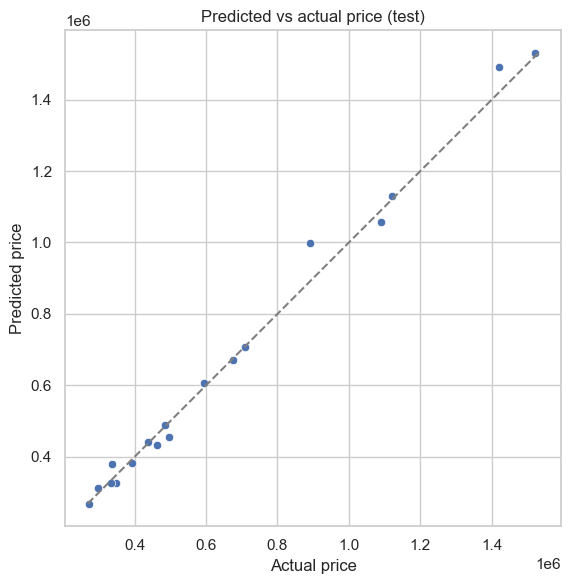

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, ax=ax)
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max()),
]
ax.plot(lims, lims, color="gray", linestyle="--")
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title("Predicted vs actual price (test)")
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()
